PREPARATION + CHSH 
===================


In [3]:

import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_gate_map, plot_error_map

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes import TrivialLayout, FullAncillaAllocation, EnlargeWithAncilla, ApplyLayout
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
%matplotlib inline
import numpy as np 


In [4]:
service = QiskitRuntimeService(
    channel="ibm_cloud", 
    token="AmSXCY7RdEfmuP8C9sKYv_CoPD17p6F7xfhTYZ8t_5YD"
)
real_backend = service.backend("ibm_torino")
noisy_sim = AerSimulator.from_backend(real_backend)
sim = AerSimulator()


target = real_backend.target

qiskit_runtime_service._discover_account:WARNING:2026-03-25 18:27:13,120: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-25 18:27:19,527: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-25 18:27:19,529: Using instance: open-instance, plan: open


In [5]:
print(f"Connected to: {real_backend.name}")
print(f"Number of qubits: {real_backend.num_qubits}")
print(f"Status: {real_backend.status().status_msg}")

Connected to: ibm_torino
Number of qubits: 133
Status: active


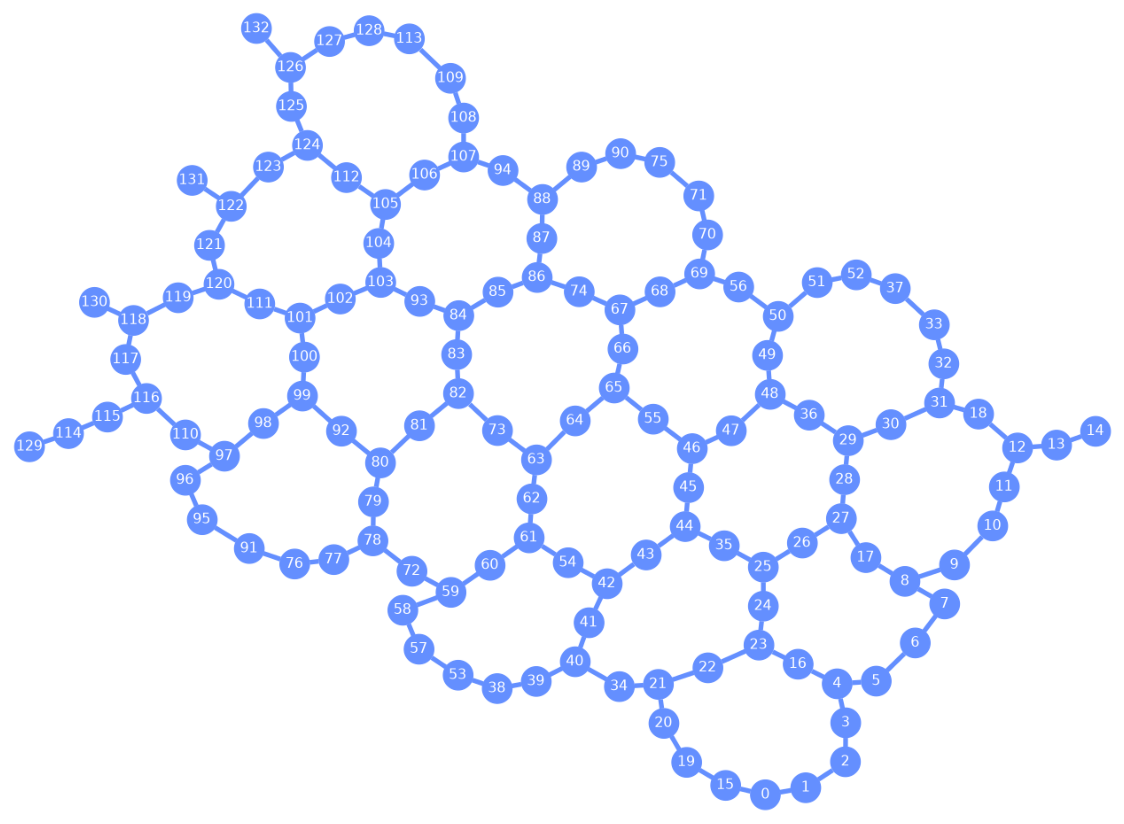

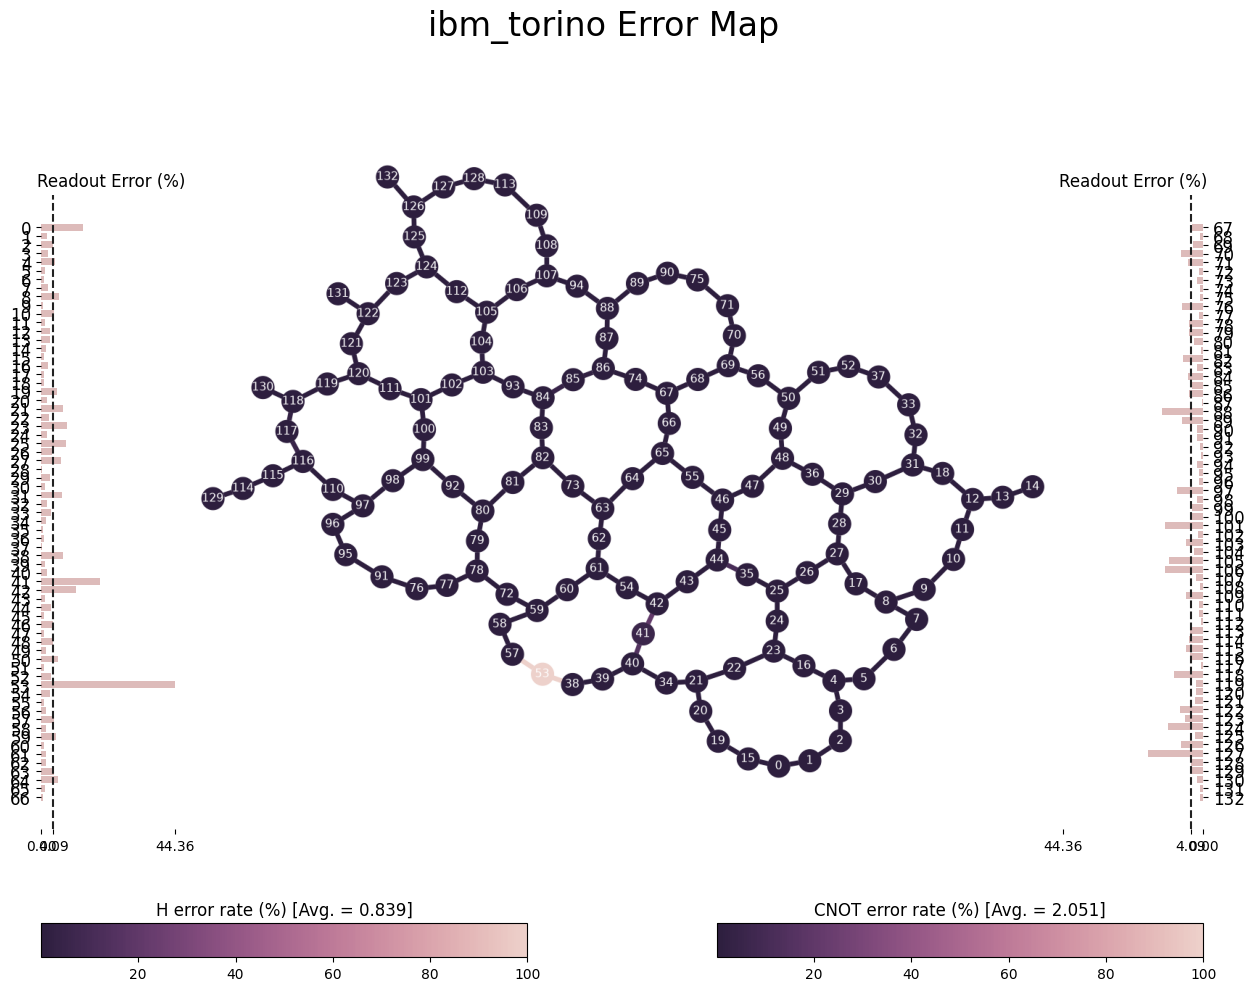

In [6]:
# Plot the physical connections (Topology)
plot_gate_map(real_backend)
plt.show()

# Plot a heat map of the gate errors across the whole chip
plot_error_map(real_backend)
plt.show()

In [15]:
q = QuantumRegister(21)
c = ClassicalRegister(2)
qc = QuantumCircuit(q, c)

In [16]:
l1 = [42,43,44,45,46,55,65,64,63,62,61,54]
l2 = [46,47,48,49,50,56,69,68,67,66,65,55]

#l1 = [4,5,6,7,8,17,27,26,25,24,23,16]
#l2 = [8,9,10,11,12,18,31,30,29,28,27,17]

#l1 = [38,53,57,58,59,60,61,54,42,41,40,39,38]
#l2 = [42,54,61,62,63,64,65,55,46,45,44,43]


lists = [l1, l2]

initial_layout = []
seen = set()

for lst in lists:
    for x in lst:
        if x not in seen:
            initial_layout.append(x)
            seen.add(x)

print(initial_layout)

[42, 43, 44, 45, 46, 55, 65, 64, 63, 62, 61, 54, 47, 48, 49, 50, 56, 69, 68, 67, 66]


In [17]:
pm = generate_preset_pass_manager(
    backend=real_backend, 
    optimization_level=1, 
    initial_layout=initial_layout
)

In [18]:
transpiled_qc = pm.run(qc)


In [19]:

def chsh (qc, q0, q1, c0, c1):

    settings = [
        ("A0B0", False, -np.pi/4),
        ("A0B1", False, -3*np.pi/4),
        ("A1B0", True, -np.pi/4),
        ("A1B1", True, -3*np.pi/4)
    ]
    results_E=[]

    for label, apply_h, ry_angle in settings:
        

        qc2= qc.copy()
        if apply_h:
            qc2.h(q0)

        qc2.ry(ry_angle, q1)
        qc2.measure(q0, c0)
        qc2.measure(q1, c1)
        
        t_qc = pm.run(qc2)

        #sim = AerSimulator() #StatevectorSimulator
        job = noisy_sim.run(t_qc, shots=10000)
        #job = sim.run(t_qc, shots=10000)
      
        result = job.result()
        counts = result.get_counts()

        s00 = counts.get('00', 0)
        s11 = counts.get('11', 0)
        e01 = counts.get('01', 0)
        e10 = counts.get('10', 0)
        

        total = s00 + s11 + e01 + e10

        E = (s00 + s11 - e01 - e10) / total if total > 0 else 0
        results_E.append(E)

        print(f"Setting {label} | E = {E:.4f}")

        if len(results_E)==4:
            S = results_E[0] - results_E[1] + results_E[2] + results_E[3]
            print("\n" + "="*30)
            print(f"CHSH S-value: {S:.4f}")
            print("Violation?" , "YES" if abs(S) > 2 else "NO")
            print("="*30)
            print("\nTranspiled Circuit for the real backend:")
            t_qc.draw('mpl')
            plt.show()




We entangle qubits 42 and 56

In [20]:
qc.h(q[0])
qc.cx(q[0], q[1])
qc.swap(q[1], q[2])
qc.swap(q[2], q[3])
qc.swap(q[3], q[4])
qc.swap(q[4], q[12])
qc.swap(q[12], q[13])
qc.swap(q[13], q[14])
qc.swap(q[14], q[15])
qc.swap(q[15], q[16])





Original Circuit:


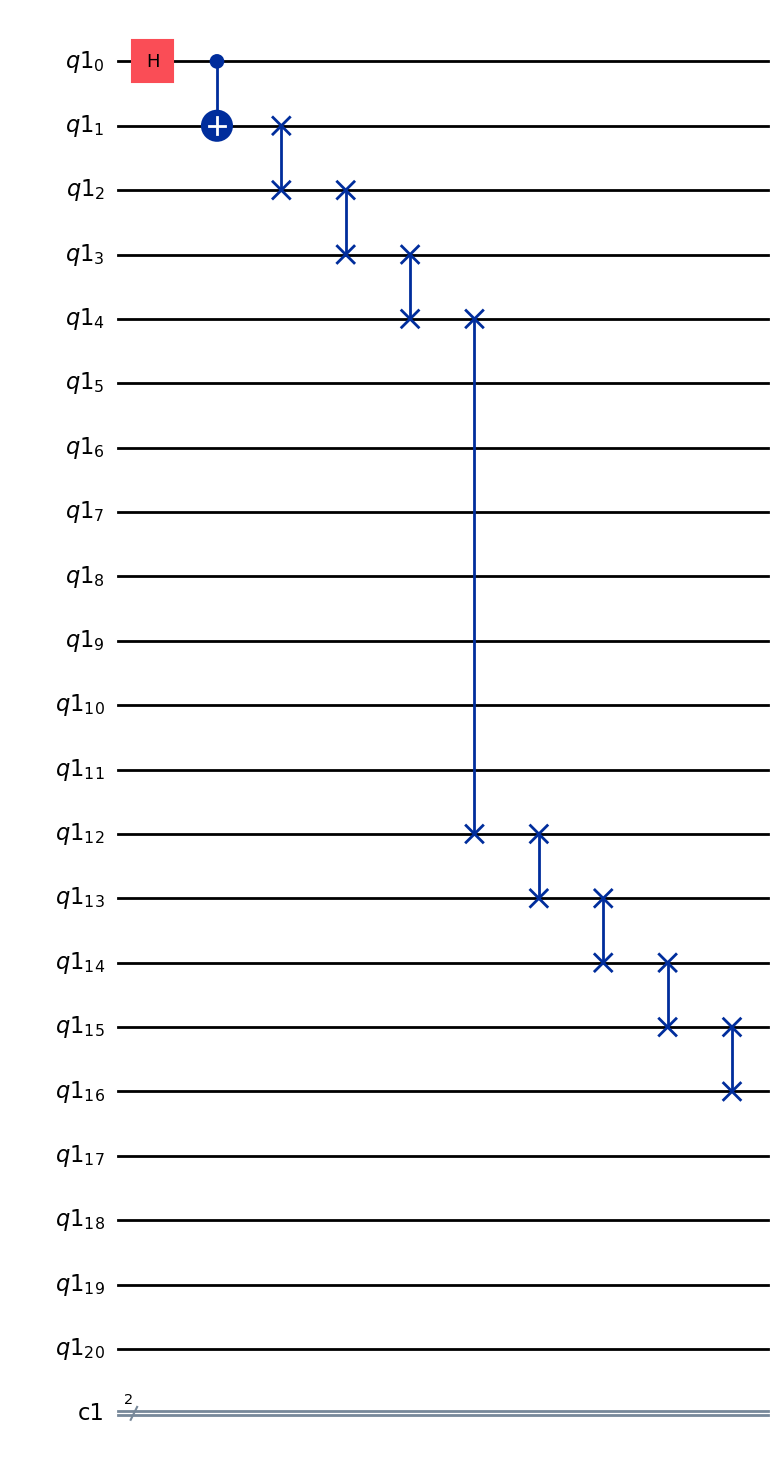

In [21]:
print("Original Circuit:")
qc.draw('mpl')
plt.show()

Setting A0B0 | E = 0.4862
Setting A0B1 | E = -0.4908
Setting A1B0 | E = 0.4692
Setting A1B1 | E = 0.4806

CHSH S-value: 1.9268
Violation? NO

Transpiled Circuit for the real backend:


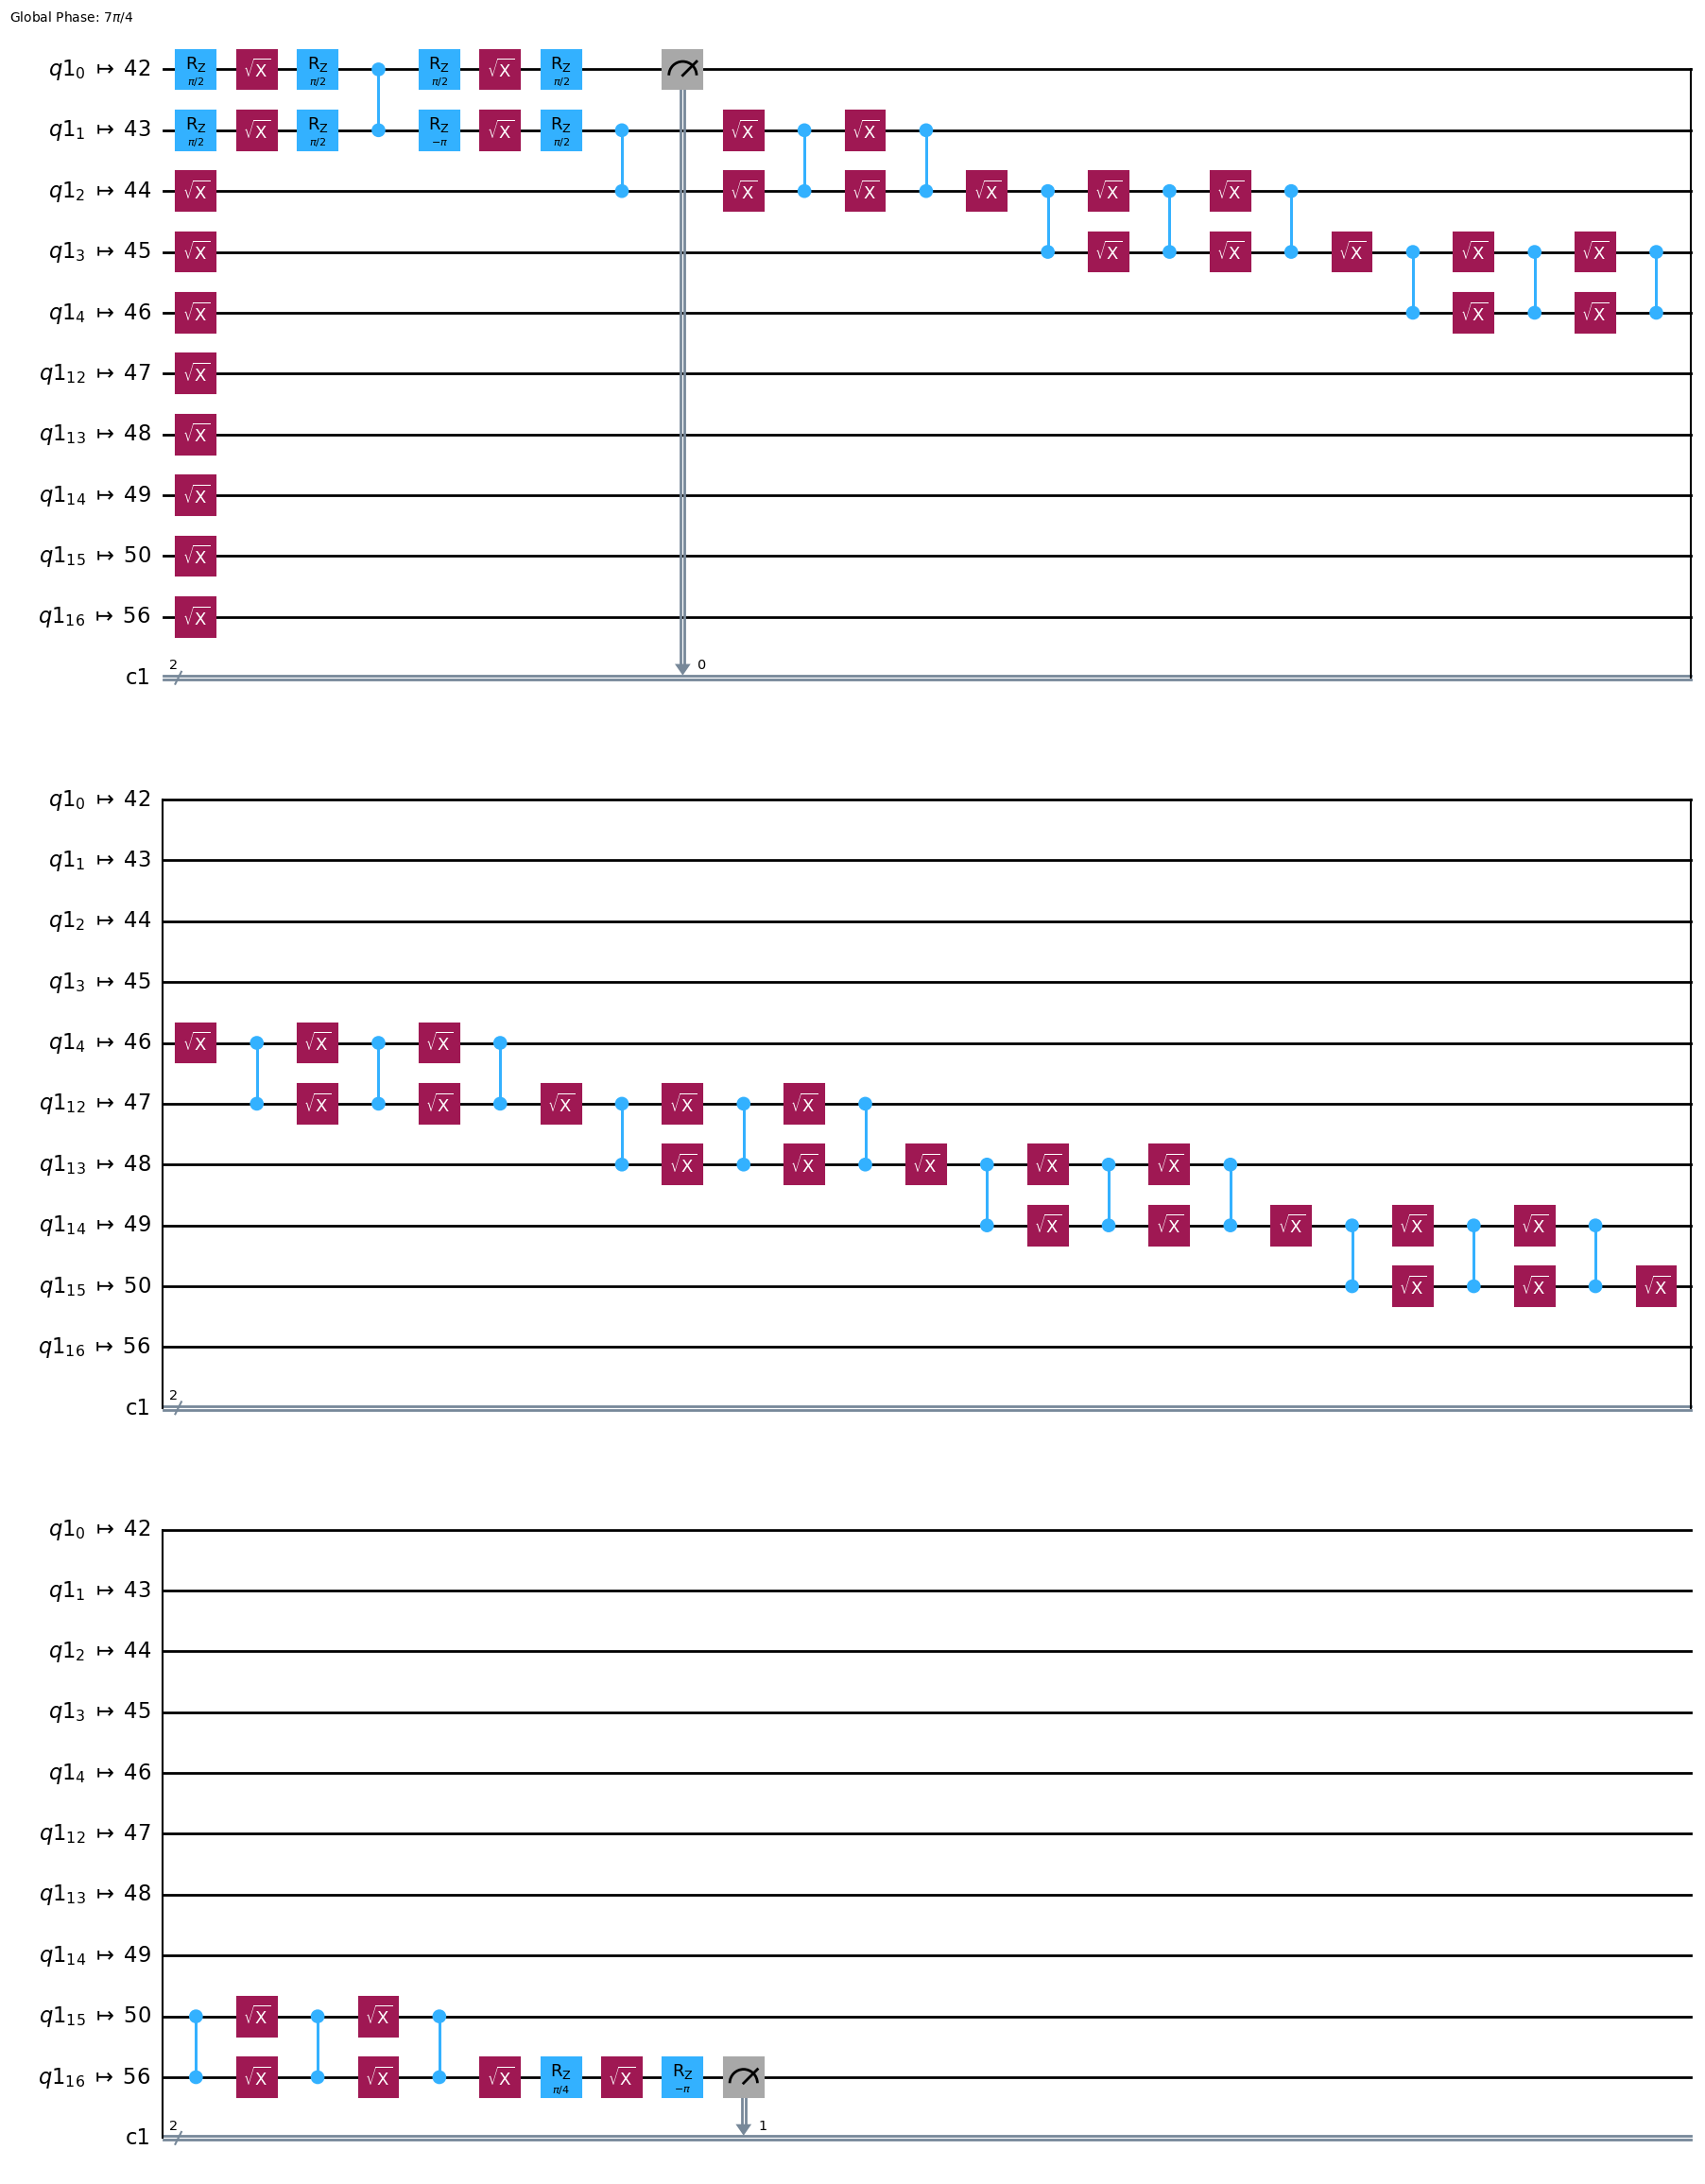

In [22]:
chsh(qc, q[0], q[16], c[0], c[1])
